# BUS 32120
# Midterm

**Midterm Group 7:** Lawrence Li, Jeremy Ye

## AI Usage Disclosure
We used a generative AI assistant (ChatGPT) to help draft boilerplate code structure and writing.  
All team members reviewed, understood, and can explain every code section in the accompanying video.

## Introduction
Early-stage founders and investors evaluating opportunities in China’s elder caregiving services market—specifically caregiver training and staffing/dispatch

### Motivation
This market is shaped by:
- Demand growth from population aging
- Labor supply constraints in caregiving (we use a simple proxy available in public data)

We use public indicators to build a simple, interpretable demand–supply “tension” signal to motivate deeper research.

### Key questions
1. Is China’s aging trend rising (65+ share)?  
2. Is the healthcare workforce proxy (nurses & midwives per 1,000) rising?  
3. Is the implied elderly per nurse/midwife ratio rising (tension proxy)?


In [23]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data source: World Bank API

We download World Bank indicators via REST API.  
To ensure we pull all rows even when results span multiple pages, we include a small pagination loop.

### Indicators used (World Bank codes)
- SP.POP.65UP.TO.ZS — Population ages 65 and above (% of total population)  
- SP.POP.65UP.TO — Population ages 65 and above, total  
- SH.MED.NUMW.P3 — Nurses and midwives (per 1,000 people)  
- SP.POP.TOTL — Population, total  
- NY.GDP.PCAP.CD — GDP per capita (current US$)

Note: “Nurses & midwives per 1,000” is a proxy. It is not identical to certified elder caregivers.

In [24]:
def fetch_country_indicator(country_code, indicator_code, per_page=20000):
    # Example endpoint:
    # https://api.worldbank.org/v2/country/CHN/indicator/SP.POP.65UP.TO.ZS
    base_url = f"https://api.worldbank.org/v2/country/{country_code}/indicator/{indicator_code}"

    page = 1
    rows = []

    while True:
        params = {
            "format": "json",
            "per_page": per_page,
            "page": page
        }

        response = requests.get(base_url, params=params, timeout=30)
        response.raise_for_status()
        payload = response.json()

        meta = payload[0]   # includes total pages
        data = payload[1]   # list of records

        # Convert each record to a simple dict row
        for item in data:
            rows.append({
                "country": item["country"]["value"],
                "iso3": country_code,
                "year": int(item["date"]),
                "value": item["value"]
            })

        if page >= meta["pages"]:
            break
        page += 1

    return pd.DataFrame(rows)

In [25]:
# Countries we compare (simple benchmarks)
countries = ["CHN", "JPN", "KOR"]

# Indicators we need
indicators = {
    "pop65_pct": "SP.POP.65UP.TO.ZS",
    "pop65_total": "SP.POP.65UP.TO",
    "nurses_per_1000": "SH.MED.NUMW.P3",
    "pop_total": "SP.POP.TOTL",
    "gdp_pc_usd": "NY.GDP.PCAP.CD"
}

frames = []

for col, ind in indicators.items():
    one_indicator_all_countries = []
    for c in countries:
        df_tmp = fetch_country_indicator(c, ind, per_page=20000)   # columns: iso3,country,year,value
        one_indicator_all_countries.append(df_tmp)

    df_ind = pd.concat(one_indicator_all_countries, ignore_index=True)
    df_ind = df_ind.rename(columns={"value": col})
    frames.append(df_ind[["iso3", "country", "year", col]])

df = frames[0]
for f in frames[1:]:
    df = df.merge(f, on=["iso3", "country", "year"], how="outer")

df = df[(df["year"] >= 1990) & (df["year"] <= 2024)].copy()
df = df.sort_values(["iso3", "year"]).reset_index(drop=True)


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso3             105 non-null    object 
 1   country          105 non-null    object 
 2   year             105 non-null    int64  
 3   pop65_pct        105 non-null    float64
 4   pop65_total      105 non-null    int64  
 5   nurses_per_1000  75 non-null     float64
 6   pop_total        105 non-null    int64  
 7   gdp_pc_usd       105 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 6.7+ KB


In [27]:
df.head()

,iso3,country,year,pop65_pct,pop65_total,nurses_per_1000,pop_total,gdp_pc_usd
0,CHN,China,1990,5.345157,60677425,0.845,1135185000,318.503354
1,CHN,China,1991,5.452704,62748626,NaN,1150780000,334.130288
2,CHN,China,1992,5.576618,64965926,NaN,1164970000,367.822652
3,CHN,China,1993,5.726530,67483718,NaN,1178440000,378.939353
4,CHN,China,1994,5.885333,70143458,NaN,1191835000,475.677874


In [28]:
df.tail()

,iso3,country,year,pop65_pct,pop65_total,nurses_per_1000,pop_total,gdp_pc_usd
100,KOR,"Korea, Rep.",2020,15.822166,8201616,8.527,51836239,33645.771955
101,KOR,"Korea, Rep.",2021,16.659641,8624619,8.912,51769539,37518.463531
102,KOR,"Korea, Rep.",2022,17.484646,9034766,9.086,51672569,34822.404840
103,KOR,"Korea, Rep.",2023,18.335024,9481521,NaN,51712619,35674.095996
104,KOR,"Korea, Rep.",2024,19.273513,9974248,NaN,51751065,36238.639908


## Data quality checks

- Missingness rate by column
- Duplicate check for (iso3, year)
- Basic validity checks (percent in [0, 100], non-negative where appropriate)


In [29]:
# Missingness
missing_rate = df.isna().mean().sort_values(ascending=False)
print("Missing rate by column:")
display(missing_rate)

Missing rate by column:


nurses_per_1000    0.285714
iso3               0.000000
country            0.000000
year               0.000000
pop65_pct          0.000000
pop65_total        0.000000
pop_total          0.000000
gdp_pc_usd         0.000000
dtype: float64

In [30]:
# Duplicates
dup_count = df.duplicated(subset=["iso3", "year"]).sum()
print("Duplicate rows on (iso3, year):", dup_count)

Duplicate rows on (iso3, year): 0


In [31]:
# Range checks
pct_bad = ((df["pop65_pct"] < 0) | (df["pop65_pct"] > 100)).sum()
print("pop65_pct out-of-range count:", pct_bad)

pop65_pct out-of-range count: 0


In [32]:
for c in ["pop65_total", "pop_total", "nurses_per_1000", "gdp_pc_usd"]:
    bad = (df[c] < 0).sum()
    print(f"{c} negative count:", bad)

pop65_total negative count: 0
pop_total negative count: 0
nurses_per_1000 negative count: 0
gdp_pc_usd negative count: 0


## Feature engineering

We create:
1) Estimated nurse total: nurse_total_est = nurses_per_1000 / 1000 * pop_total
2) Tension proxy: elderly_per_nurse_est = pop65_total / nurse_total_est
3) YoY growth for demand: pop65_total_yoy (by country)

We flag unusually large YoY values for review instead of deleting data blindly.

In [33]:
df_feat = df.copy()

In [34]:
# Estimated nurse total (avoid divide-by-zero)
df_feat["nurse_total_est"] = (df_feat["nurses_per_1000"] / 1000.0) * df_feat["pop_total"]
df_feat.loc[df_feat["nurse_total_est"] <= 0, "nurse_total_est"] = np.nan

In [35]:
# Tension proxy
df_feat["elderly_per_nurse_est"] = df_feat["pop65_total"] / df_feat["nurse_total_est"]

In [36]:
# YoY growth for pop65_total
df_feat["pop65_total_yoy"] = df_feat.groupby("iso3")["pop65_total"].pct_change()

In [37]:
# Flag large YoY changes (diagnostic only)
df_feat["flag_large_yoy"] = df_feat["pop65_total_yoy"].abs() > 0.15

In [38]:
# Show China flagged years (if any)
df_feat[(df_feat["iso3"] == "CHN") & (df_feat["flag_large_yoy"])][["year", "pop65_total_yoy", "pop65_total", "pop_total"]].sort_values("pop65_total_yoy", ascending=False).head(10)

,year,pop65_total_yoy,pop65_total,pop_total


## EDA

Charts (4):
1) 65+ share over time (CHN vs JPN vs KOR)  
2) Nurses & midwives per 1,000 over time (CHN vs JPN vs KOR)  
3) Tension proxy: elderly per nurse over time (CHN vs JPN vs KOR)  
4) Latest-year scatter (only 3 points): GDP per capita vs tension proxy

Plus:
- A simple correlation table for China (over time)
- A “latest year snapshot” table for the three countries

In [39]:
def plot_three_country_lines(df_in, y_col, title, ylabel):
    plt.figure(figsize=(9, 5))
    for iso3, g in df_in.groupby("iso3"):
        plt.plot(g["year"], g[y_col], label=iso3)
    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()

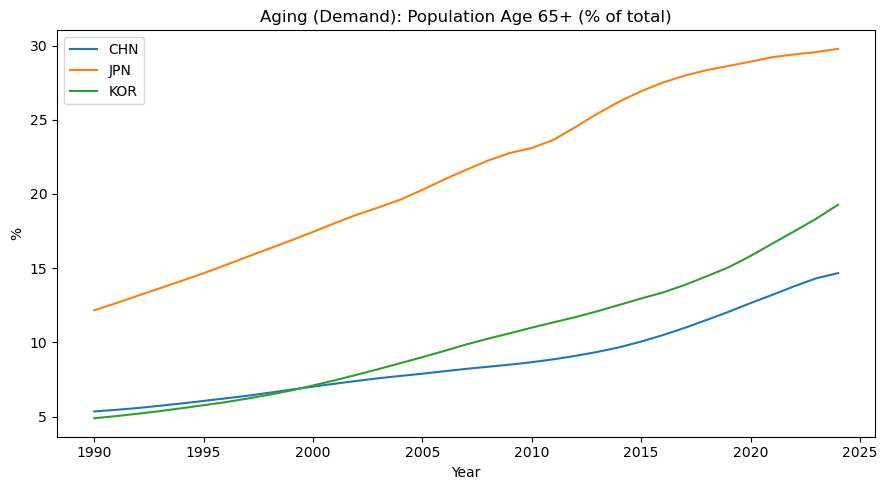

In [40]:
plot_three_country_lines(
    df_feat.dropna(subset=["pop65_pct"]),
    "pop65_pct",
    "Aging (Demand): Population Age 65+ (% of total)",
    "%"
)

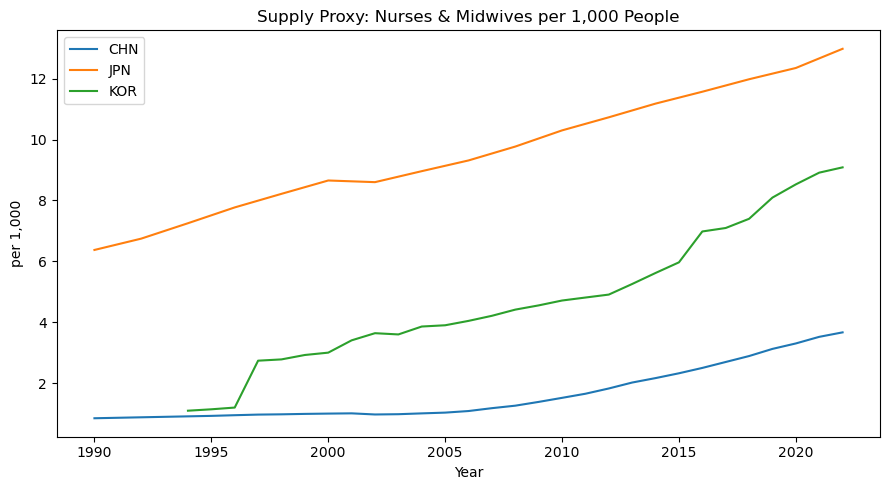

In [41]:
plot_three_country_lines(
    df_feat.dropna(subset=["nurses_per_1000"]),
    "nurses_per_1000",
    "Supply Proxy: Nurses & Midwives per 1,000 People",
    "per 1,000"
)

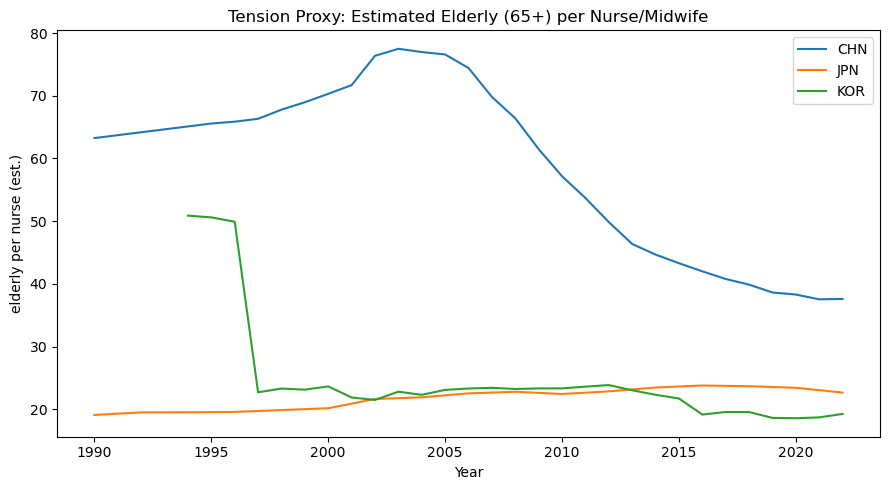

In [42]:
plot_three_country_lines(
    df_feat.dropna(subset=["elderly_per_nurse_est"]),
    "elderly_per_nurse_est",
    "Tension Proxy: Estimated Elderly (65+) per Nurse/Midwife",
    "elderly per nurse (est.)"
)

In [46]:
valid_years = df_feat.dropna(subset=["gdp_pc_usd", "elderly_per_nurse_est"])["year"].unique()
latest_valid_year = int(max(valid_years))

snap = df_feat[df_feat["year"] == latest_valid_year][
    ["iso3","country","year","pop65_pct","nurses_per_1000","gdp_pc_usd","elderly_per_nurse_est"]
].copy()

print("Using latest year with valid tension proxy:", latest_valid_year)
display(snap)

Using latest year with valid tension proxy: 2022


,iso3,country,year,pop65_pct,nurses_per_1000,gdp_pc_usd,elderly_per_nurse_est
32,CHN,China,2022,13.781930,3.666,12970.605641,37.593918
67,JPN,Japan,2022,29.402647,12.980,34065.643896,22.652271
102,KOR,"Korea, Rep.",2022,17.484646,9.086,34822.404840,19.243503


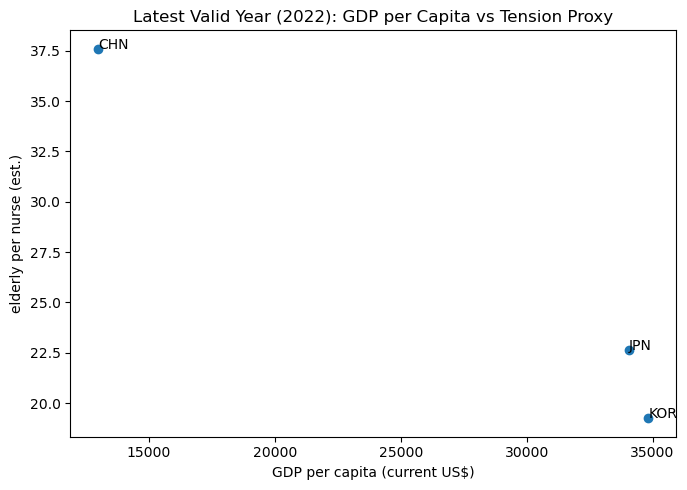

In [47]:
# Scatter with labels (only CHN/JPN/KOR)
snap2 = snap.dropna(subset=["gdp_pc_usd","elderly_per_nurse_est"])

plt.figure(figsize=(7,5))
plt.scatter(snap2["gdp_pc_usd"], snap2["elderly_per_nurse_est"])

for _, r in snap2.iterrows():
    plt.text(r["gdp_pc_usd"], r["elderly_per_nurse_est"], r["iso3"])

plt.title(f"Latest Valid Year ({latest_valid_year}): GDP per Capita vs Tension Proxy")
plt.xlabel("GDP per capita (current US$)")
plt.ylabel("elderly per nurse (est.)")
plt.tight_layout()
plt.show()

In [48]:
# Simple correlation table for China (over time)
china = df_feat[df_feat["iso3"] == "CHN"][
    ["pop65_pct", "nurses_per_1000", "gdp_pc_usd", "elderly_per_nurse_est"]
].dropna()

corr = china.corr(numeric_only=True)
print("China correlations (over time):")
corr

China correlations (over time):


,pop65_pct,nurses_per_1000,gdp_pc_usd,elderly_per_nurse_est
pop65_pct,1.000000,0.973483,0.974075,-0.844395
nurses_per_1000,0.973483,1.000000,0.986696,-0.926674
gdp_pc_usd,0.974075,0.986696,1.000000,-0.935994
elderly_per_nurse_est,-0.844395,-0.926674,-0.935994,1.000000


## Conclusion & Next Steps

### Key takeaways

- Aging demand is rising in all three countries. By 2024, the 65+ share is about 15% in China, 30% in Japan, and 19% in Korea.
- China’s caregiving supply proxy is much lower. In the latest year where the nurse indicator is available for all three (2022), nurses & midwives per 1,000 people are 3.67 (China) vs 12.98 (Japan) vs 9.09 (Korea).
- China shows the highest “tension proxy.” In 2022, estimated elderly (65+) per nurse/midwife is 37.59 (China) vs 22.65 (Japan) vs 19.24 (Korea), suggesting a larger labor constraint under this proxy.
- China’s tension proxy moves with workforce density over time. The correlation between elderly per nurse and nurses per 1,000 is strongly negative (~ -0.93), consistent with “more workforce capacity leads to lower tension.”

### Limitations

- Proxy mismatch: “Nurses & midwives” are not the same as elder caregivers, so this is only a screening-level supply measure.
- Missing recent years: The nurse indicator is missing for newer years (e.g., 2023–2024), so the tension comparison uses the latest valid year (2022) rather than the calendar latest year.
- Too aggregated: Country-level data hides major regional differences inside China that matter for go-to-market decisions.

### If we had more time / additional datasets

- Direct caregiver supply data: number of certified caregivers, training completions, employment, turnover/attrition, vacancy rates.
- China sub-national demand & supply: province/city 65+ (and ideally 80+) population, caregiver counts, elder-care facility/bed capacity, utilization.
- Basic business / unit-economics inputs: caregiver wages, training costs, placement rates, service pricing, retention outcomes.